# A Deep Dive into Bayesian Model Comparison with BayesFlow

_Author: Jerry M. Huang_

In this notebook, we take a deep dive into Bayesian model comparison by demonstrating the `ModelComparisonWorkflow` in BayesFlow. We will demonstrate two common scenarios for model comparison based on two families of scoring rules that BayesFlow has to offer:

* **PMP (Posterior Model Probability) rules** — the network outputs softmax probabilities over all models.
* **Bayes factor rules** — the network outputs $M−1$ log Bayes factors $log K_{k,ref}$ relative to a reference model.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

import bayesflow as bf
from bayesflow.workflows import ModelComparisonWorkflow
from bayesflow.scoring_rules import (
    CrossEntropyScore,
    SquaredScore,
    PolynomialScore,
    ExponentialScore,
    LogisticScore,
    AlphaExponentialScore,
    LPOPExponentialScore,
    AlphaLogExponentialScore,
)
import bayesflow.diagnostics.plots as bf_plots

## Two families of scoring rules

BayesFlow supports two families of scoring rules for model comparison:

**PMP (Posterior Model Probability) rules** — the network outputs softmax probabilities over all models.  Diagnostics: confusion matrix and calibration curves.

| Class | Loss |
|-------|------|
| `CrossEntropyScore` | Categorical cross-entropy (default) |
| `SquaredScore` | Brier score (squared error on softmax probabilities) |
| `PolynomialScore` | Polynomial scoring rule; `alpha=2` recovers the Brier score |

**Bayes factor rules** — the network outputs M−1 log Bayes factors log K_{k,ref} relative to a reference model.  Diagnostics: blind coverage test and Bayes factor recovery.

| Class | Notes |
|-------|-------|
| `ExponentialScore` | Baseline Bayes factor rule |
| `LogisticScore` | Softplus-based; numerically more stable |
| `AlphaExponentialScore` | Exponential × polynomial envelope (default α=0.5) |
| `LPOPExponentialScore` | **Recommended** — l-POP transform before exp |
| `AlphaLogExponentialScore` | Log-sum-exp variant (default α=1.0) |

## Simulators

To demonstrate with an application scenario, we discriminate between four models within the generalized autoregressive conditional heteroscedasticity (GARCH) model family, commonly used in computational finance.

| Model | Key feature |
|-------|-------------|
| ARCH(1) | Short-memory ARCH: volatility shocks decay in one step |
| GARCH(1,1) | Persistent volatility clustering, Gaussian innovations |
| GJR-GARCH(1,1) | Leverage effect: negative shocks inflate variance more |
| GARCH-t | GARCH(1,1) with Student-t innovations; heavier tails |

Rather than hand-crafting summary statistics, we feed the raw return series directly into a `TimeSeriesTransformer` summary network and let the network learn what to look at — a more principled and typically more powerful approach.

Each model is defined by a **prior function** that draws parameters, and all four share a single **likelihood function** that runs the GARCH recursion.  `bf.make_simulator` chains them so that the prior's output dict is forwarded automatically as keyword arguments to the likelihood.

The unified likelihood covers all four models via its optional parameters:

| Model | `beta` | `gamma` | `nu` |
|-------|--------|---------|------|
| ARCH(1) | 0 (default) | 0 (default) | None (default) |
| GARCH(1,1) | sampled | 0 (default) | None (default) |
| GJR-GARCH(1,1) | sampled | sampled | None (default) |
| GARCH-t | sampled | 0 (default) | sampled |

The prior functions are also reused later for importance-sampling log marginal likelihood estimates, so each model's prior is defined exactly once.

In [11]:
def arch_prior():
    return dict(
        omega=np.random.uniform(5e-5, 2e-4),
        alpha=np.random.uniform(0.10, 0.40),   # α < 1 ensures stationarity
        beta =0.0,
        gamma=0.0,
        nu   =np.inf,
        mu   =np.random.uniform(-5e-4, 5e-4),
    )


def garch_prior():
    return dict(
        omega=np.random.uniform(1e-6, 5e-5),
        alpha=np.random.uniform(0.05, 0.15),
        beta =np.random.uniform(0.75, 0.84),   # α + β ≤ 0.99
        gamma=0.0,
        nu   =np.inf,
        mu   =np.random.uniform(-5e-4, 5e-4),
    )


def gjr_prior():
    return dict(
        omega=np.random.uniform(1e-6, 5e-5),
        alpha=np.random.uniform(0.01, 0.04),
        gamma=np.random.uniform(0.12, 0.22),   # α + γ/2 + β ≤ 0.99; strong leverage makes asymmetry clearly detectable
        beta =np.random.uniform(0.73, 0.83),
        nu   =np.inf,
        mu   =np.random.uniform(-5e-4, 5e-4),
    )


def garcht_prior():
    return dict(
        omega=np.random.uniform(1e-6, 5e-5),
        alpha=np.random.uniform(0.05, 0.15),
        beta =np.random.uniform(0.75, 0.84),   # α + β ≤ 0.99
        gamma=0.0,
        nu   =np.random.uniform(3.0, 5.0),     # ν ∈ (2, 4] → infinite kurtosis; ν ∈ (4, 5] → kurtosis ≥ 6; always visually distinct from Gaussian
        mu   =np.random.uniform(-5e-4, 5e-4),
    )

In [12]:
@njit
def simulate_garch(omega, alpha, mu, beta, gamma, nu, T, burn_in):
    """JIT-compiled GARCH recursion. nu=inf selects Gaussian innovations."""
    T_total = T + burn_in
    returns = np.empty(T_total)
    eps = 0.0
    sigma2 = omega / max(1.0 - alpha - gamma * 0.5 - beta, 1e-6)
    use_gaussian = np.isinf(nu)

    for t in range(T_total):
        I_neg = 1.0 if eps < 0.0 else 0.0
        sigma2 = omega + (alpha + gamma * I_neg) * eps * eps + beta * sigma2
        if sigma2 < 1e-10:
            sigma2 = 1e-10
        elif sigma2 > 1.0:
            sigma2 = 1.0
        if use_gaussian:
            z = np.random.randn()
        else:
            z = np.random.standard_t(nu) * np.sqrt((nu - 2.0) / nu)
        eps = np.sqrt(sigma2) * z
        returns[t] = mu + eps

    out = returns[burn_in:].copy()
    for i in range(len(out)):
        if out[i] < -1.0:
            out[i] = -1.0
        elif out[i] > 1.0:
            out[i] = 1.0
    return out


def garch_model(omega, alpha, mu, beta=0.0, gamma=0.0, nu=None, T=500, burn_in=50, **kwargs):
    """Shared GARCH model for all variants.

    beta=0, gamma=0, nu=None/inf  →  ARCH(1)
    gamma=0, nu=None/inf          →  GARCH(1,1)
    nu=None/inf                   →  GJR-GARCH(1,1)
    nu provided and finite        →  GARCH-t (Student-t innovations scaled to unit variance)
    """
    nu_val = np.inf if (nu is None or np.isinf(float(nu))) else float(nu)
    out = simulate_garch(float(omega), float(alpha), float(mu),
                      float(beta), float(gamma), nu_val, T, burn_in)
    return {"returns": out[:, np.newaxis].astype(np.float32)}


# Warm up both JIT branches (Gaussian and Student-t) to pay compile cost once.
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, np.inf, 60, 10)
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, 5.0,    60, 10)
print("JIT warmup complete.")

JIT warmup complete.


In [13]:
arch_simulator      = bf.make_simulator([arch_prior, garch_model])
garch_simulator     = bf.make_simulator([garch_prior, garch_model])
gjr_simulator       = bf.make_simulator([gjr_prior, garch_model])
garcht_simulator    = bf.make_simulator([garcht_prior, garch_model])

simulators = [arch_simulator, garch_simulator, gjr_simulator, garcht_simulator]
model_names = ["ARCH", "GARCH", "GJR", "GARCH-t"]

### Prior predictive check

A single draw from each simulator illustrates the qualitative differences the network will learn to detect.

(500, 1)
(500, 1)
(500, 1)
(500, 1)


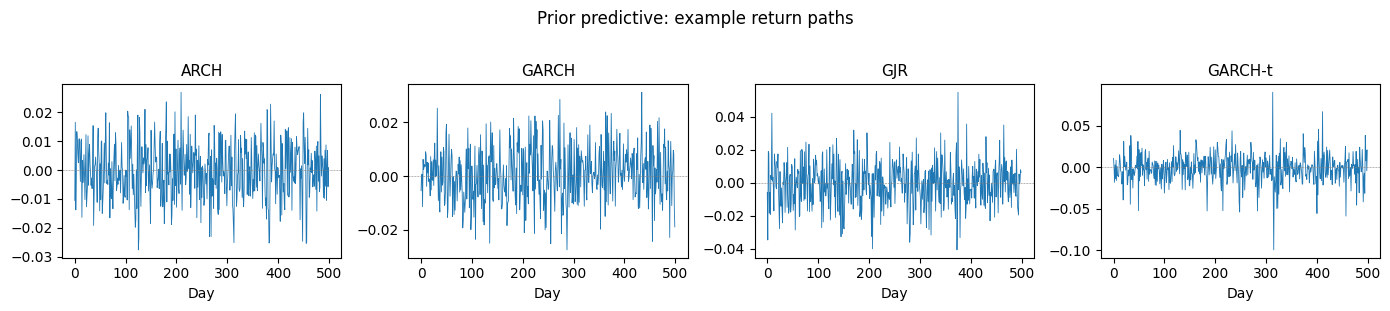

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=False)
for ax, sim, name in zip(axes, simulators, model_names):
    path = sim.sample((5,))["returns"][4, :]
    print(path.shape)
    ax.plot(path, linewidth=0.6)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Day")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
plt.suptitle("Prior predictive: example return paths", y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Shared adapter for both workflows.
# `returns` comes out of the simulator as (batch, T, 1) float32 — already the
# shape both TimeSeriesTransformer and DeepSet expect — so no as_set is needed.
garch_adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate("model_indices", into="inference_variables")
    .concatenate(["returns"], into="summary_variables")
)

---

## Part 1 — PMP Scoring Rules

PMP scoring rules train the network to output softmax probabilities over all models. The three available rules differ only in their loss function; they share the same network architecture and produce identical output shapes.

We train with the default `CrossEntropyScore`.  To switch to another PMP rule, pass `scoring_rule=SquaredScore()` or `scoring_rule=PolynomialScore(alpha=3.0)` — everything else stays the same.

In [16]:
pmp_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    adapter=garch_adapter,
    summary_network="time_series_transformer",
    model_names=model_names,
    scoring_rule=CrossEntropyScore(), 
    standardize="summary_variables"
)

# Alternative PMP scoring rules (same API, just swap scoring_rule=):
#
# pmp_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=SquaredScore()
# )
#
# pmp_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=PolynomialScore(alpha=2.0)  # alpha=2 recovers Brier score
# )

In [17]:
history_pmp = pmp_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 1.4941 - scoring_rule/inference_scoring_rule: 1.4941
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.4639 - scoring_rule/inference_scoring_rule: 1.4639
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.3877 - scoring_rule/inference_scoring_rule: 1.3877
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.4272 - scoring_rule/inference_scoring_rule: 1.4272
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.3005 - scoring_rule/inference_scoring_rule: 1.3005
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 1.3928 - scoring_rule/inference_scoring_rule: 1.3928
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 1.3457 - scoring_rule/inference_scoring_rule: 1.3457
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 1.2725 - scoring_rule/inference_scoring_rule: 1.2725
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.9431 - scoring_rule/infe

INFO:bayesflow:Training completed in 4.05 minutes.


### Diagnostics — PMP rules

`plot_default_diagnostics` detects the active scoring rule and automatically produces the appropriate plots.  For PMP rules these are:

- **Loss curve** — training and validation cross-entropy over epochs.
- **Confusion matrix** — rows = true model, columns = predicted model (argmax of PMPs).
- **Calibration curves** — per-model ECE-annotated reliability diagrams.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 0.14 seconds.


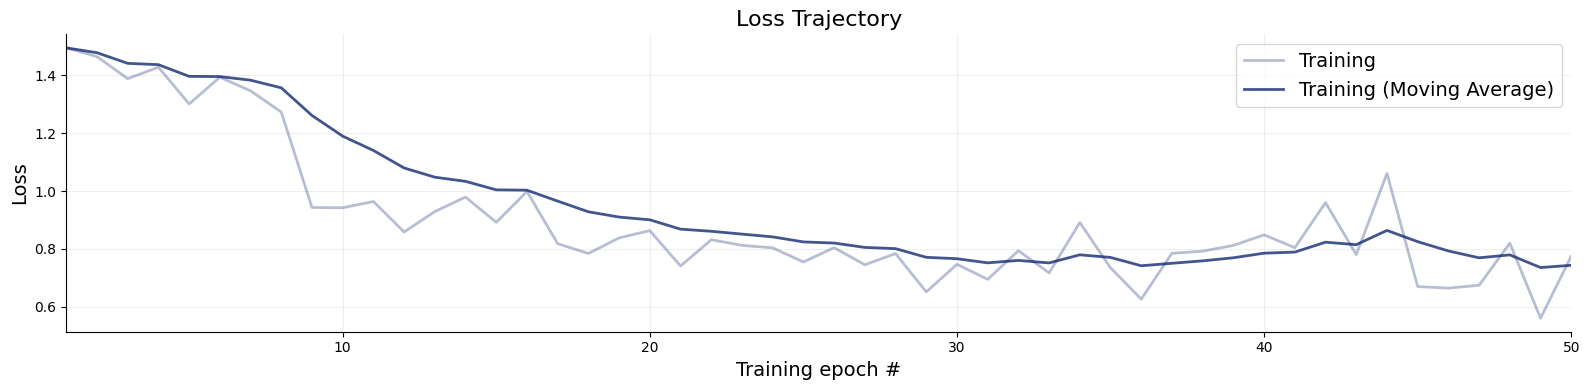

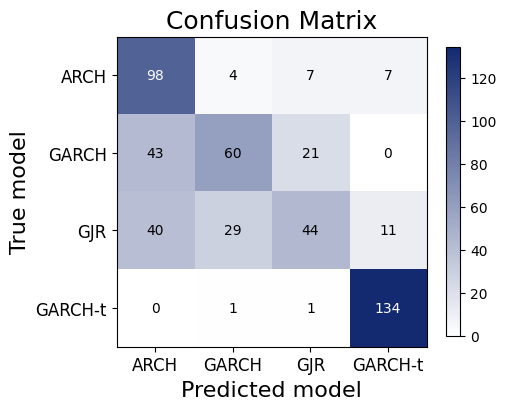

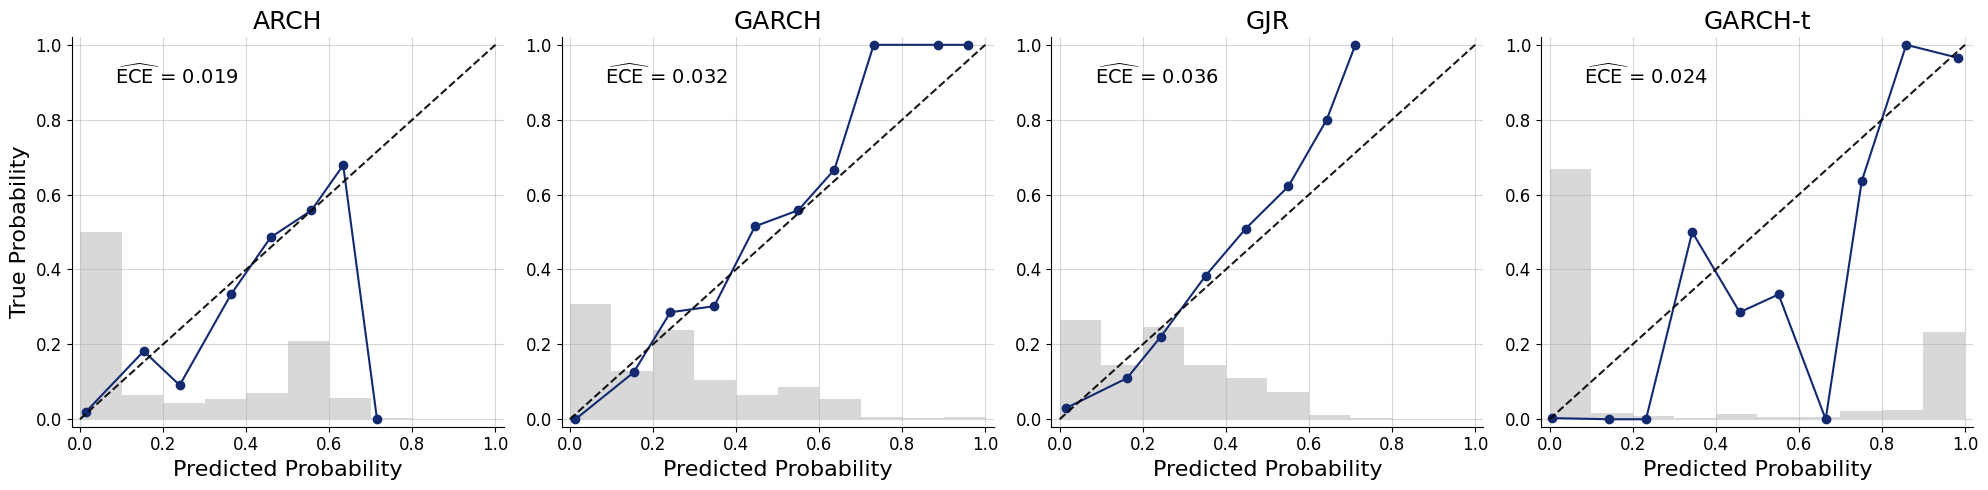

In [18]:
figs_pmp = pmp_workflow.plot_default_diagnostics(test_data=500)

## Part 2 — Bayes Factor Scoring Rules

Bayes factor scoring rules train the network to output **log Bayes factors** log K_{k,0} for each competing model k relative to the reference model (model 0 by default). The output shape is `(num_datasets, num_models - 1)`.

All five rules share the same network structure and diagnostics; they differ in how they penalize incorrect rankings:

| Rule | Key property |
|------|--------------|
| `ExponentialScore` | Baseline; may be unstable when log BF magnitudes are large |
| `LogisticScore` | Softplus penalty; numerically more stable than exponential |
| `AlphaExponentialScore(alpha)` | Exponential × polynomial envelope; α=0.5 default |
| `LPOPExponentialScore(alpha)` | **Recommended** — l-POP transform regularises large outputs |
| `AlphaLogExponentialScore(alpha)` | Log-sum-exp variant; interpolates between max and sum |

We train with `LPOPExponentialScore`, which applies the leaky parity-odd power transform $J_\alpha(x) = x + x|x|^{(\alpha−1)}$ before the exponential, giving well-calibrated estimates even when true log Bayes factors are large.

In [ ]:
bayes_factor_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    adapter=garch_adapter,
    summary_network="time_series_transformer",
    model_names=model_names,
    scoring_rule=LPOPExponentialScore(alpha=2.0),
    standardize="all"
)

# Other Bayes factor scoring rules (same API, just swap scoring_rule=):
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=ExponentialScore()
# )
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=LogisticScore()
# )
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=AlphaExponentialScore(alpha=0.5)
# )
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=AlphaLogExponentialScore(alpha=1.0)
# )

In [53]:
history_bayes_factor = bayes_factor_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 2.9883 - scoring_rule/inference_scoring_rule: 2.9883
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 2.9222 - scoring_rule/inference_scoring_rule: 2.9222
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 2.4069 - scoring_rule/inference_scoring_rule: 2.4069
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.3209 - scoring_rule/inference_scoring_rule: 2.3209
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.0394 - scoring_rule/inference_scoring_rule: 2.0394
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.0127 - scoring_rule/inference_scoring_rule: 2.0127
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 1.9948 - scoring_rule/inference_scoring_rule: 1.9948
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.5968 - scoring_rule/inference_scoring_rule: 2.5968
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.3002 - scoring_rule/infe

INFO:bayesflow:Training completed in 4.42 minutes.


### Diagnostics — Bayes factor rules

`plot_default_diagnostics` detects the Bayes factor rule and automatically switches to
the **blind coverage test** (Jeffrey & Wandelt 2024) instead of the PMP diagnostics.

For PMP rules these are:

- **Loss curve** — training and validation loss over epochs.
- **Blind coverage** — one panel per competing model.  For each marginal quantile
  level α the plot shows what fraction of each model group's predicted log K falls at
  or below the α-quantile of the *full* (model-label-free) predicted log K
  distribution.  A well-calibrated estimator pushes the reference-model curve *above*
  the diagonal and the competing-model curve *below* it.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 0.75 seconds.


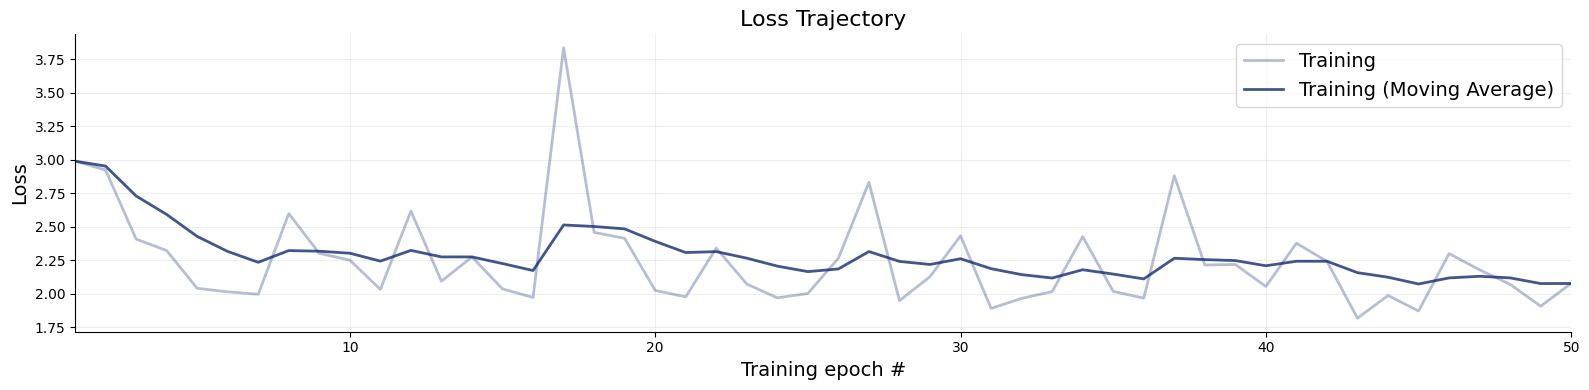

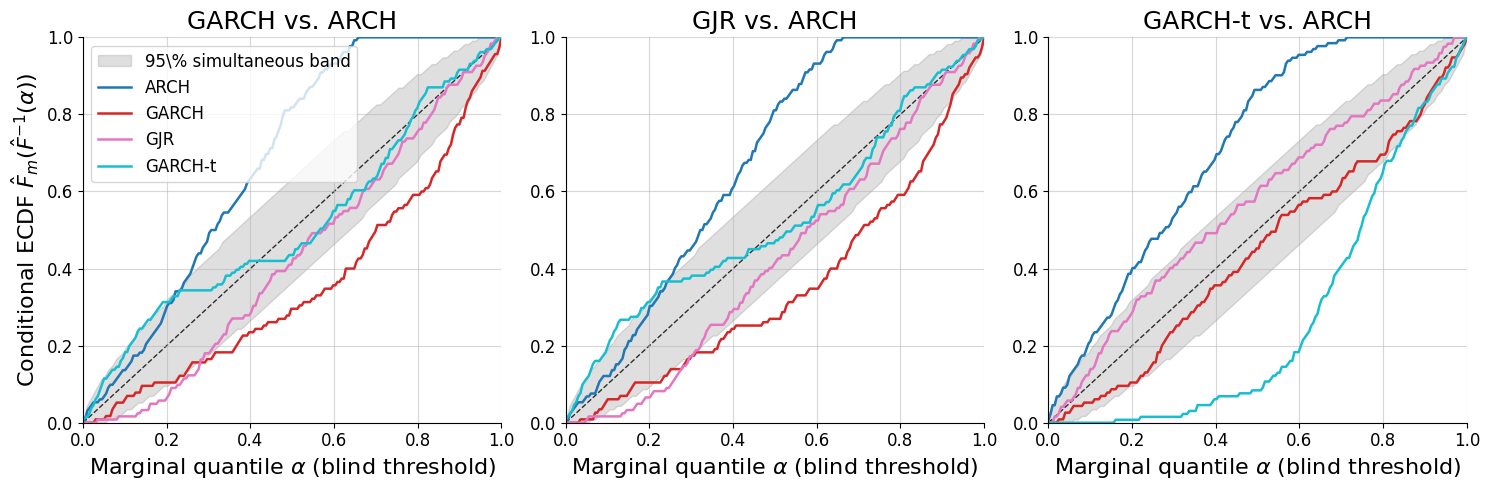

In [54]:
figures = bayes_factor_workflow.plot_default_diagnostics(test_data=500)

### Bayes factor recovery via posterior importance sampling

Prior IS is consistent but can have high variance when the prior is diffuse relative to the likelihood.  A lower-variance alternative uses the amortized posterior as the importance proposal:

$$\log \hat{p}(\mathbf{y} \mid \mathcal{M}_k) = \log\!\sum_{s=1}^{S} w_s - \log S, \qquad \log w_s = \log p(\mathbf{y} \mid \theta_s, \mathcal{M}_k) + \log p(\theta_s \mid \mathcal{M}_k) - \log q(\theta_s \mid \mathbf{y}, \mathcal{M}_k)$$

where $\theta_s \sim q(\theta \mid \mathbf{y}, \mathcal{M}_k)$ is a draw from the amortized posterior.  Because the proposal is concentrated near the high-likelihood region, the effective sample size is much higher than with prior IS.

We train one `BasicWorkflow` parameter-estimation (PE) network per model, share the same `TimeSeriesTransformer` backbone, then evaluate IS weights by combining the GARCH log-likelihood, the uniform prior, and the PE network's `log_prob`.

In [ ]:
from bayesflow.workflows import BasicWorkflow

# Variable parameter names per model (fixed params — beta=0, gamma=0, nu=inf — are excluded).
PARAM_NAMES = {
    "ARCH":    ["omega", "alpha", "mu"],
    "GARCH":   ["omega", "alpha", "beta", "mu"],
    "GJR":     ["omega", "alpha", "beta", "gamma", "mu"],
    "GARCH-t": ["omega", "alpha", "beta", "nu", "mu"],
}

# One PE workflow per model, reusing the named simulators from the top of the notebook.
_pe_simulators = {
    "ARCH":    arch_simulator,
    "GARCH":   garch_simulator,
    "GJR":     gjr_simulator,
    "GARCH-t": garcht_simulator,
}

pe_workflows = {}
for name in model_names:
    pe_adapter = (
        bf.Adapter()
        .convert_dtype("float64", "float32")
        .concatenate(PARAM_NAMES[name], into="inference_variables")
        .concatenate(["returns"], into="summary_variables")
    )
    pe_workflows[name] = BasicWorkflow(
        simulator=_pe_simulators[name],
        adapter=pe_adapter,
        summary_network="time_series_transformer",
    )

print("PE workflows built:", list(pe_workflows.keys()))

In [ ]:
histories_pe = {}
for name, wf in pe_workflows.items():
    print(f"\n--- Training PE workflow for {name} ---")
    histories_pe[name] = wf.fit_online(
        epochs=30,
        num_batches_per_epoch=100,
        batch_size=32,
    )

In [ ]:
def uniform_log_prior(params_bs: dict, bounds: dict) -> np.ndarray:
    """log p(θ | M) = sum of independent Uniform log-densities.

    params_bs : dict of (B, S) arrays, one per variable parameter.
    bounds    : dict of {param_name: (lo, hi)}.
    Returns   : (B, S) array.
    """
    log_p = 0.0
    for name, (lo, hi) in bounds.items():
        p = params_bs[name]
        log_p = log_p + np.where((p >= lo) & (p <= hi), -np.log(hi - lo), -np.inf)
    return log_p


def _garch_log_lik_bs(params_bs: dict, y: np.ndarray) -> np.ndarray:
    """Vectorized GARCH log-likelihood over (B, S) parameter draws.

    params_bs : dict of (B, S) arrays (only variable params — missing ones default to 0 / inf).
    y         : (B, T) observed returns.
    Returns   : (B, S) log-likelihoods.
    """
    B, T = y.shape
    S = next(iter(params_bs.values())).shape[1]

    omega = params_bs["omega"]
    alpha = params_bs["alpha"]
    mu    = params_bs["mu"]
    beta  = params_bs.get("beta",  np.zeros((B, S)))
    gamma = params_bs.get("gamma", np.zeros((B, S)))
    nu    = params_bs.get("nu",    np.full((B, S), np.inf))

    use_t    = not np.all(np.isinf(nu))
    log_liks = np.zeros((B, S))
    sigma2   = np.maximum(omega / np.maximum(1.0 - alpha - gamma / 2.0 - beta, 1e-6), 1e-10)

    for t in range(T):
        et    = y[:, t, None] - mu       # (B, 1) broadcast → (B, S)
        I_neg = (et < 0).astype(float)
        sigma2 = np.maximum(sigma2, 1e-10)
        if use_t:
            log_liks += _t_logpdf(et, sigma2, nu)
        else:
            log_liks += _gauss_logpdf(et, sigma2)
        sigma2 = np.maximum(
            omega + (alpha + gamma * I_neg) * et**2 + beta * sigma2,
            1e-10,
        )

    return log_liks

In [ ]:
def garch_log_ml_post_is(
    pe_workflow: BasicWorkflow,
    param_names: list,
    prior_bounds: dict,
    y: np.ndarray,
    S: int = 100,
    log_prob_batch_size: int = 64,
) -> np.ndarray:
    """Posterior IS estimate of log p(y | M) for one GARCH model.

    Draws S posterior samples per dataset via the amortized PE workflow, then weights
    by the GARCH log-likelihood, the uniform prior, and the inverse posterior density.

    Parameters
    ----------
    pe_workflow       : trained BasicWorkflow for model M.
    param_names       : variable parameter names in the adapter's concatenation order.
    prior_bounds      : {param_name: (lo, hi)} uniform prior bounds.
    y                 : (B, T) observed return series.
    S                 : IS sample count per dataset.
    log_prob_batch_size : mini-batch size for log_prob calls (avoids OOM with TST).

    Returns
    -------
    log_ml : (B,) array of log marginal likelihood estimates.
    """
    B, T = y.shape
    returns_3d = y[:, :, None].astype(np.float32)  # (B, T, 1)

    # --- Draw S posterior samples for all B datasets in one call ---
    # pe_workflow.sample returns {param_name: (B, S, 1)} for each variable param
    # (the trailing dim comes from SequentialSimulator's expand_outputs=True)
    samples = pe_workflow.sample(
        num_samples=S,
        conditions={"returns": returns_3d},
    )

    # Squeeze trailing singleton dim: (B, S, 1) → (B, S)
    params_bs = {name: samples[name][..., 0] for name in param_names}

    # --- log p(y | θ, M): vectorized GARCH log-likelihood ---
    log_lik = _garch_log_lik_bs(params_bs, y)   # (B, S)

    # --- log p(θ | M): independent uniform priors ---
    log_prior = uniform_log_prior(params_bs, prior_bounds)   # (B, S)

    # --- log q(θ | y, M): amortized posterior log-density ---
    # Flatten (B, S, 1) → (B*S, 1) for each param; repeat returns (B, T, 1) → (B*S, T, 1).
    returns_rep  = np.repeat(returns_3d, S, axis=0)              # (B*S, T, 1)
    params_flat  = {name: samples[name].reshape(B * S, 1) for name in param_names}

    log_q_chunks = []
    for start in range(0, B * S, log_prob_batch_size):
        end        = min(start + log_prob_batch_size, B * S)
        batch_data = {"returns": returns_rep[start:end]}
        batch_data |= {name: params_flat[name][start:end] for name in param_names}
        log_q_chunks.append(pe_workflow.log_prob(data=batch_data))

    log_q = np.concatenate(log_q_chunks).reshape(B, S)   # (B, S)

    # --- IS weights and log marginal likelihood ---
    log_w = log_lik + log_prior - log_q   # (B, S)
    return logsumexp(log_w, axis=1) - np.log(S)   # (B,)


def compute_garch_log_bfs_post_is(
    returns: np.ndarray,
    pe_workflows: dict,
    S: int = 100,
    reference: int = 0,
    log_prob_batch_size: int = 64,
) -> np.ndarray:
    """Log Bayes factors via posterior IS for all four GARCH models.

    Parameters
    ----------
    returns      : (B, T) observed return series.
    pe_workflows : {model_name: BasicWorkflow} trained PE networks.
    S            : IS sample count per dataset.
    reference    : index into model_names for the reference model.

    Returns
    -------
    log_bfs : (B, 3) array of log K_{k, reference} for the three competing models.
    """
    ref_name = model_names[reference]
    log_mls  = {}
    for name in model_names:
        print(f"  log p(y | {name}) ...")
        log_mls[name] = garch_log_ml_post_is(
            pe_workflows[name],
            PARAM_NAMES[name],
            PRIOR_BOUNDS[name],
            returns,
            S=S,
            log_prob_batch_size=log_prob_batch_size,
        )

    competing = [n for n in model_names if n != ref_name]
    return np.column_stack([log_mls[n] - log_mls[ref_name] for n in competing])   # (B, 3)

In [ ]:
import time as _time

# Reuse the 500 test datasets simulated for prior IS.
# returns_test has shape (500, T) — produced earlier in cell 5cf3853c.
pred_log_bfs_post = bayes_factor_workflow.predict(conditions=test_data_garch)   # (500, 3)

print("Computing posterior IS ground truth (S=100 per dataset)...")
_t0 = _time.perf_counter()
true_log_bfs_post = compute_garch_log_bfs_post_is(
    returns_test,
    pe_workflows,
    S=100,
)
print(f"Done in {_time.perf_counter() - _t0:.1f}s")   # expect ~1-2 min

fig_post = bf_plots.bayes_factor_recovery(
    pred_log_bayes_factors=pred_log_bfs_post,
    true_log_bayes_factors=true_log_bfs_post,
    true_models=test_data_garch["model_indices"],
    model_names=model_names,
    reference_model=0,
    add_corr=True,
)
plt.suptitle("Bayes factor recovery — posterior IS ground truth", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Sanity check: prior IS and posterior IS should agree on average.
# Large per-sample differences are expected (different estimator variance);
# the scatter should fall on the diagonal without systematic bias.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = list(zip(range(3), [n for n in model_names if n != model_names[0]]))
for ax, (k, name) in zip(axes, pairs):
    ax.scatter(true_log_bfs_garch[:, k], true_log_bfs_post[:, k],
               s=4, alpha=0.4, color="#132a70")
    lims = np.quantile(
        np.concatenate([true_log_bfs_garch[:, k], true_log_bfs_post[:, k]]),
        [0.01, 0.99],
    )
    ax.plot(lims, lims, "k--", linewidth=0.8)
    ax.set_xlabel(f"Prior IS  log K({name}/ARCH)")
    ax.set_ylabel(f"Posterior IS  log K({name}/ARCH)")
    ax.set_title(name)
plt.suptitle("Prior IS vs Posterior IS — should agree on the diagonal", y=1.02)
plt.tight_layout()
plt.show()